# Test: MCMC Data Augmentation

Tests for `src/optim/mcmc_augment.py`:
- `chord_interval`  — analytical chord intersection with Polytope #1
- `activation_pattern` — ReLU activation pattern extraction
- `find_augmented_point` — hit-and-run MCMC to find x' with different q-model pattern

Switch between MLP and CNN via the **Config** cell below.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

# Project root = one level above this notebook
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, ROOT)

import numpy as np
import torch

from src.models.networks           import FashionMLP_Large, FashionCNN_Small
from src.quantization.quantize     import quantize_model
from src.optim.build_polytopes     import build_all_polytopes
from src.optim.build_polytopes_cnn import build_cnn_all_polytopes
from src.optim.mcmc_augment        import (
    chord_interval, activation_pattern,
    find_augmented_point,
    find_augmented_point_margin, _qmodel_margin,
    find_augmented_points_walk,
    select_diverse_representatives,
)

## Config — switch MODEL_TYPE here

In [11]:
MODEL_TYPE  = "mlp"         # "mlp" or "cnn"
STRATEGY    = "walk"        # "activation"  →  find_augmented_point        (Strategy A)
                            # "margin"      →  find_augmented_point_margin  (Strategy B)
                            # "walk"        →  find_augmented_points_walk   (Strategy C)
SAMPLE_IDX  = 0
BITS        = 4       # quantization bit-width used for the q-model
MAX_TRIES   = 200     # max MCMC attempts              (strategies A and B)

# Strategy C / walk parameters
NB_AUG_POINTS = 100  # collect up to this many reps (set large to explore broadly)
MAX_STEPS   = 5000   # hard cap on walk steps

# Diversity selection (strategy C only)
# After collecting NB_AUG_POINTS reps, select K_DIVERSE maximally spread ones.
# Set USE_DIVERSITY = False to use reps in discovery order instead.
USE_DIVERSITY = True
K_DIVERSE   = 10     # number of diverse reps to keep / display

SEED        = 13
rng = np.random.default_rng(SEED)


MODEL_PATHS = {
    "mlp": os.path.join(ROOT, "checkpoints/fashion_mlp_best.pth"),
    "cnn": os.path.join(ROOT, "checkpoints/fashion_cnn_best.pth"),
}
DATA_PATHS = {
    "mlp": os.path.join(ROOT, "data/fashionMNIST_correct_mlp.pt"),
    "cnn": os.path.join(ROOT, "data/fashionMNIST_correct_cnn.pt"),
}

print(f"Project root  : {ROOT}")
print(f"Strategy      : {STRATEGY}")
if STRATEGY == "walk":
    print(f"NB_AUG_POINTS : {NB_AUG_POINTS}  (collect up to this many reps per sample)")
    print(f"MAX_STEPS     : {MAX_STEPS}   (hard cap on walk steps)")
    print(f"USE_DIVERSITY : {USE_DIVERSITY}  (greedy farthest-point selection)")
    print(f"K_DIVERSE     : {K_DIVERSE}   (representatives to keep after diversity selection)")

Project root  : /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes
Strategy      : walk
NB_AUG_POINTS : 100  (collect up to this many reps per sample)
MAX_STEPS     : 5000   (hard cap on walk steps)
USE_DIVERSITY : True  (greedy farthest-point selection)
K_DIVERSE     : 10   (representatives to keep after diversity selection)


## Load model, q-model, and sample

In [12]:
# --- Full-precision model ---
if MODEL_TYPE == "cnn":
    model = FashionCNN_Small()
else:
    model = FashionMLP_Large()

device = "mps" if torch.backends.mps.is_available() else "cpu"

state_dict = torch.load(MODEL_PATHS[MODEL_TYPE], 
                        weights_only=True, 
                        map_location=device)
model.load_state_dict(state_dict)
model.eval()
print(f"Loaded {MODEL_TYPE.upper()} model")

# --- Quantized model (single bit-width) ---
qmodel = quantize_model(model, bits=BITS)
qmodel.eval()
print(f"Quantized model: {BITS} bits")

# --- Sample ---
dataset = torch.load(DATA_PATHS[MODEL_TYPE], weights_only=False)
x_raw, c = dataset[SAMPLE_IDX]
c = int(c)
print(f"Sample {SAMPLE_IDX}: shape={x_raw.shape}  label={c}")

Loaded MLP model
Quantized model: 4 bits
Sample 0: shape=torch.Size([1, 28, 28])  label=9


## Build Polytope #1 (A_base, b_base)

In [13]:
# Prepare input batch and build polytopes — same convention as run_volumes.py
if MODEL_TYPE == "cnn":
    x_batch = x_raw.unsqueeze(0)             # (1, 1, 28, 28)
    x0      = x_raw.unsqueeze(0)             # same shape passed to find_augmented_point
    A_base, b_base, _ = build_cnn_all_polytopes(model, {BITS: qmodel}, x_batch, c)
else:
    x_batch = x_raw.flatten().unsqueeze(0)   # (1, 784)
    x0      = x_raw.flatten().unsqueeze(0)   # same shape passed to find_augmented_point
    A_base, b_base, _ = build_all_polytopes(model, {BITS: qmodel}, x_batch, c)

# Convert to numpy for LP / chord computations
A_np = A_base.detach().cpu().numpy()   # (m, 784)
b_np = b_base.detach().cpu().numpy()   # (m,)

print(f"Polytope #1:  A shape = {A_np.shape}")

# Sanity check: x0 must be feasible (all Ax+b <= 0)
x0_flat = x0.detach().cpu().numpy().flatten()
slack = A_np @ x0_flat + b_np
print(f"Max constraint violation at x0: {slack.max():.2e}  (should be <= 0 up to some numerical tolerance)")

Polytope #1:  A shape = (1929, 784)
Max constraint violation at x0: -3.67e-03  (should be <= 0 up to some numerical tolerance)


## Test 1 — `chord_interval`

In [14]:
n_test_directions = 10
print(f"Testing chord_interval on {n_test_directions} random directions...\n")

# chord_interval adds +1e-6 to s internally, so endpoints have slack ≈ 1e-6
# by construction.  Floating-point in the large matmul adds ~1e-7, so we use
# a slightly larger test tolerance (1e-5) to avoid spurious failures.
eps_test = 1e-5

all_ok = True
for i in range(n_test_directions):
    d = rng.standard_normal(x0_flat.shape[0])
    d /= np.linalg.norm(d)

    t_min, t_max = chord_interval(x0_flat, A_np, b_np, d)

    # 1. t_min < 0 < t_max  (x0 is strictly interior)
    sign_ok = t_min < 0 < t_max

    # 2. Both endpoints satisfy Ax+b <= 0  (up to eps_test tolerance)
    x_lo = x0_flat + t_min * d
    x_hi = x0_flat + t_max * d
    lo_ok = (A_np @ x_lo + b_np).max() <= eps_test
    hi_ok = (A_np @ x_hi + b_np).max() <= eps_test

    status = "OK" if (sign_ok and lo_ok and hi_ok) else "FAIL"
    if status == "FAIL":
        all_ok = False

    chord_len = t_max - t_min
    print(f"  dir {i:2d}: t_min={t_min:+.2e}  t_max={t_max:+.2e}  chord={chord_len:.2e}  "
          f"sign={'ok' if sign_ok else 'FAIL'}  "
          f"endpoints={'ok' if (lo_ok and hi_ok) else 'FAIL'}  [{status}]")

print(f"\nAll tests passed: {all_ok}")

Testing chord_interval on 10 random directions...

  dir  0: t_min=-1.25e-01  t_max=+5.92e-01  chord=7.16e-01  sign=ok  endpoints=ok  [OK]
  dir  1: t_min=-1.89e-01  t_max=+6.71e-01  chord=8.60e-01  sign=ok  endpoints=ok  [OK]
  dir  2: t_min=-6.44e-01  t_max=+1.88e-01  chord=8.32e-01  sign=ok  endpoints=ok  [OK]
  dir  3: t_min=-2.41e-01  t_max=+1.57e-01  chord=3.98e-01  sign=ok  endpoints=ok  [OK]
  dir  4: t_min=-9.52e-01  t_max=+1.29e-01  chord=1.08e+00  sign=ok  endpoints=ok  [OK]
  dir  5: t_min=-7.14e-01  t_max=+2.90e-01  chord=1.00e+00  sign=ok  endpoints=ok  [OK]
  dir  6: t_min=-8.99e-01  t_max=+1.60e-01  chord=1.06e+00  sign=ok  endpoints=ok  [OK]
  dir  7: t_min=-6.04e-01  t_max=+1.25e-01  chord=7.29e-01  sign=ok  endpoints=ok  [OK]
  dir  8: t_min=-1.24e+00  t_max=+1.03e-01  chord=1.34e+00  sign=ok  endpoints=ok  [OK]
  dir  9: t_min=-4.16e-02  t_max=+9.40e-02  chord=1.36e-01  sign=ok  endpoints=ok  [OK]

All tests passed: True


## Test 2 — `activation_pattern`

In [15]:
# Pattern at x0 for full-precision model and q-model
pat_model  = activation_pattern(x0, model)
pat_qmodel = activation_pattern(x0, qmodel)

n_neurons = len(pat_model)
n_active_model  = pat_model.sum()
n_active_qmodel = pat_qmodel.sum()
n_differ = (pat_model != pat_qmodel).sum()

print(f"Total ReLU neurons\t: {n_neurons}")
print(f"Active in model  (fp)\t: {n_active_model}  ({100*n_active_model/n_neurons:.1f}%)")
print(f"Active in qmodel ({BITS}b)\t: {n_active_qmodel}  ({100*n_active_qmodel/n_neurons:.1f}%)")
print(f"Neurons differing at x0\t: {n_differ}  ({100*n_differ/n_neurons:.1f}%)")
print()

# Determinism check: calling twice should give identical results
pat2 = activation_pattern(x0, qmodel)
print(f"Determinism check: patterns identical = {np.array_equal(pat_qmodel, pat2)}")

Total ReLU neurons	: 1920
Active in model  (fp)	: 264  (13.8%)
Active in qmodel (4b)	: 270  (14.1%)
Neurons differing at x0	: 30  (1.6%)

Determinism check: patterns identical = True


## Test 3 — augmentation (dispatched by STRATEGY)

In [16]:
import time

if STRATEGY == "walk":
    # --- Strategy C: find_augmented_points_walk ---
    t0 = time.perf_counter()
    reps_all = find_augmented_points_walk(x0, A_np, b_np, qmodel,
                                           nb_aug_points=NB_AUG_POINTS,
                                           max_steps=MAX_STEPS, rng=rng)
    elapsed = time.perf_counter() - t0

    print(f"Found {len(reps_all)} representatives in {elapsed:.2f}s\n")

    # Optional diversity selection
    if USE_DIVERSITY and len(reps_all) > K_DIVERSE:
        reps = select_diverse_representatives(reps_all, x0, k=K_DIVERSE)
        print(f"Diversity selection: kept {len(reps)}/{len(reps_all)} "
              f"(greedy farthest-point, k={K_DIVERSE})\n")
    else:
        reps = reps_all

    pat_x0 = activation_pattern(x0, qmodel)
    for k_i, xp in enumerate(reps):
        xp_flat = xp.detach().cpu().numpy().flatten()
        slack_p = A_np @ xp_flat + b_np

        inside = slack_p.max() <= 1e-5
        with torch.no_grad():
            c_pred = int(model(xp).argmax(dim=-1).item())
        pat_xp    = activation_pattern(xp, qmodel)
        n_flipped = (pat_xp != pat_x0).sum()
        delta     = np.abs(xp_flat - x0.detach().cpu().numpy().flatten())

        print(f"  rep {k_i:2d}: inside={inside} (slack={slack_p.max():.1e})  "
              f"model→{c_pred} ({'OK' if c_pred == c else 'FAIL'})  "
              f"flipped: {n_flipped}/{len(pat_x0)}  "
              f"L2={np.linalg.norm(xp_flat - x0.detach().cpu().numpy().flatten()):.3e}  "
              f"max|Δ|={delta.max():.2e}  mean|Δ|={delta.mean():.2e}")

    if not reps:
        print("  (no new equivalence class found — P1 may lie within a single q-model region)")

elif STRATEGY == "margin":
    # --- Strategy B: find_augmented_point_margin ---
    t0 = time.perf_counter()
    x_prime = find_augmented_point_margin(x0, A_np, b_np, qmodel, c,
                                          max_tries=MAX_TRIES, rng=rng)
    elapsed = time.perf_counter() - t0

    x_prime_flat = x_prime.detach().cpu().numpy().flatten()
    slack_prime  = A_np @ x_prime_flat + b_np
    inside       = slack_prime.max() <= 1e-5
    print(f"[1] x' inside Polytope #1:              {inside}  (max slack = {slack_prime.max():.2e})")

    with torch.no_grad():
        logits_prime = model(x_prime)
    c_pred   = int(logits_prime.argmax(dim=-1).item())
    class_ok = (c_pred == c)
    print(f"[2] model(x') predicts class {c_pred} (expected {c}):  {'OK' if class_ok else 'FAIL'}")

    margin_x0    = _qmodel_margin(x0,      qmodel, c)
    margin_prime = _qmodel_margin(x_prime, qmodel, c)
    improved = margin_prime < margin_x0
    print(f"[3] q-model margin at x0:  {margin_x0:.4f}")
    print(f"    q-model margin at x':  {margin_prime:.4f}  ({'improved' if improved else 'NOT improved'})")
    if margin_prime < 0:
        print(f"    → q-model MISCLASSIFIES x' (V3 = 0 expected)")
    print(f"[4] Shape of x':  {tuple(x_prime.shape)}  (expected {tuple(x0.shape)})")

else:
    # --- Strategy A: find_augmented_point ---
    t0 = time.perf_counter()
    x_prime = find_augmented_point(x0, A_np, b_np, qmodel,
                                   max_tries=MAX_TRIES, rng=rng)
    elapsed = time.perf_counter() - t0

    if x_prime is None:
        print(f"No augmented point found within {MAX_TRIES} tries.")
    else:
        x_prime_flat = x_prime.detach().cpu().numpy().flatten()
        slack_prime  = A_np @ x_prime_flat + b_np
        inside       = slack_prime.max() <= 1e-5
        print(f"[1] x' inside Polytope #1:              {inside}  (max slack = {slack_prime.max():.2e})")

        with torch.no_grad():
            logits_prime = model(x_prime)
        c_pred   = int(logits_prime.argmax(dim=-1).item())
        class_ok = (c_pred == c)
        print(f"[2] model(x') predicts class {c_pred} (expected {c}):  {'OK' if class_ok else 'FAIL'}")

        pat_qmodel = activation_pattern(x0, qmodel)
        pat_prime  = activation_pattern(x_prime, qmodel)
        n_flipped  = (pat_prime != pat_qmodel).sum()
        print(f"[3] Neurons with different q-model pattern:  {n_flipped} / {len(pat_prime)}")
        print(f"[4] Shape of x':  {tuple(x_prime.shape)}  (expected {tuple(x0.shape)})")

print(f"\nElapsed: {elapsed:.2f}s")

Found 100 representatives in 1.27s

Diversity selection: kept 10/100 (greedy farthest-point, k=10)

  rep  0: inside=True (slack=-3.6e-03)  model→9 (OK)  flipped: 10/1920  L2=5.936e+00  max|Δ|=6.37e-01  mean|Δ|=1.70e-01
  rep  1: inside=True (slack=-8.1e-04)  model→9 (OK)  flipped: 7/1920  L2=4.180e+00  max|Δ|=4.81e-01  mean|Δ|=1.19e-01
  rep  2: inside=True (slack=-6.9e-03)  model→9 (OK)  flipped: 10/1920  L2=5.098e+00  max|Δ|=5.73e-01  mean|Δ|=1.48e-01
  rep  3: inside=True (slack=-5.0e-03)  model→9 (OK)  flipped: 6/1920  L2=2.741e+00  max|Δ|=3.37e-01  mean|Δ|=7.75e-02
  rep  4: inside=True (slack=-7.9e-03)  model→9 (OK)  flipped: 9/1920  L2=3.524e+00  max|Δ|=3.66e-01  mean|Δ|=1.02e-01
  rep  5: inside=True (slack=-9.7e-03)  model→9 (OK)  flipped: 4/1920  L2=1.964e+00  max|Δ|=2.13e-01  mean|Δ|=5.61e-02
  rep  6: inside=True (slack=-1.1e-02)  model→9 (OK)  flipped: 9/1920  L2=4.734e+00  max|Δ|=5.88e-01  mean|Δ|=1.36e-01
  rep  7: inside=True (slack=-3.1e-03)  model→9 (OK)  flipped: 8/

## Acceptance rate over multiple samples

In [17]:
# Run augmentation on N_PROBE samples to estimate quality and speed.
N_PROBE = 5

results = []   # list of dicts with per-sample info
times   = []

for idx in range(N_PROBE):
    x_i, c_i = dataset[idx]
    c_i = int(c_i)

    if MODEL_TYPE == "cnn":
        x_b    = x_i.unsqueeze(0)
        x_i_in = x_i.unsqueeze(0)
        A_i, b_i, _ = build_cnn_all_polytopes(model, {BITS: qmodel}, x_b, c_i)
    else:
        x_b    = x_i.flatten().unsqueeze(0)
        x_i_in = x_i.flatten().unsqueeze(0)
        A_i, b_i, _ = build_all_polytopes(model, {BITS: qmodel}, x_b, c_i)

    A_i_np = A_i.detach().cpu().numpy()
    b_i_np = b_i.detach().cpu().numpy()

    t0 = time.perf_counter()

    if STRATEGY == "walk":
        xps = find_augmented_points_walk(x_i_in, A_i_np, b_i_np, qmodel,
                                          nb_aug_points=NB_AUG_POINTS,
                                          max_steps=MAX_STEPS, rng=rng)
        dt = time.perf_counter() - t0
        times.append(dt)

        n_reps = len(xps)
        n_inside = n_class_ok = 0
        for xp in xps:
            xp_flat = xp.detach().cpu().numpy().flatten()
            if (A_i_np @ xp_flat + b_i_np).max() <= 1e-5:
                n_inside += 1
            with torch.no_grad():
                if int(model(xp).argmax(dim=-1).item()) == c_i:
                    n_class_ok += 1

        print(f"  sample {idx}: {n_reps:2d}/{NB_AUG_POINTS} reps  ({dt:.2f}s)  "
              f"inside={n_inside}/{n_reps}  class_ok={n_class_ok}/{n_reps}")

        results.append({"idx": idx, "found": n_reps > 0, "xps": xps,
                         "x_orig": x_i, "c": c_i})

    elif STRATEGY == "margin":
        xp = find_augmented_point_margin(x_i_in, A_i_np, b_i_np, qmodel, c_i,
                                         max_tries=MAX_TRIES, rng=rng)
        dt = time.perf_counter() - t0
        times.append(dt)

        xp_flat  = xp.detach().cpu().numpy().flatten()
        slack    = (A_i_np @ xp_flat + b_i_np).max()
        inside   = slack <= 1e-5
        with torch.no_grad():
            c_pred = int(model(xp).argmax(dim=-1).item())
        class_ok = (c_pred == c_i)

        margin_orig  = _qmodel_margin(x_i_in, qmodel, c_i)
        margin_prime = _qmodel_margin(xp, qmodel, c_i)

        print(f"  sample {idx}: found  ({dt:.2f}s)  "
              f"inside={inside} (slack={slack:.1e})  "
              f"class={c_pred}={'OK' if class_ok else 'FAIL'}  "
              f"margin: {margin_orig:.3f} → {margin_prime:.3f}")

        results.append({"idx": idx, "found": True, "xp": xp,
                         "x_orig": x_i, "c": c_i})

    else:
        xp = find_augmented_point(x_i_in, A_i_np, b_i_np, qmodel,
                                  max_tries=MAX_TRIES, rng=rng)
        dt = time.perf_counter() - t0
        times.append(dt)

        if xp is None:
            print(f"  sample {idx}: NOT found   ({dt:.2f}s)")
            results.append({"idx": idx, "found": False, "xp": None,
                             "x_orig": x_i, "c": c_i})
            continue

        xp_flat  = xp.detach().cpu().numpy().flatten()
        slack    = (A_i_np @ xp_flat + b_i_np).max()
        inside   = slack <= 1e-5
        with torch.no_grad():
            c_pred = int(model(xp).argmax(dim=-1).item())
        class_ok = (c_pred == c_i)

        pat_orig  = activation_pattern(x_i_in, qmodel)
        pat_prime = activation_pattern(xp, qmodel)
        n_flip    = (pat_orig != pat_prime).sum()

        print(f"  sample {idx}: found  ({dt:.2f}s)  "
              f"inside={inside} (slack={slack:.1e})  "
              f"class={c_pred}={'OK' if class_ok else 'FAIL'}  "
              f"flipped neurons: {n_flip}")

        results.append({"idx": idx, "found": True, "xp": xp,
                         "x_orig": x_i, "c": c_i})

n_found = sum(r["found"] for r in results)
print(f"\nSamples with ≥1 result : {n_found}/{N_PROBE}  ({100*n_found/N_PROBE:.0f}%)")
print(f"Mean time/sample       : {np.mean(times):.2f}s")
if STRATEGY == "walk":
    total_reps = sum(len(r["xps"]) for r in results)
    print(f"Total reps found       : {total_reps}  (avg {total_reps/N_PROBE:.1f}/sample, target {NB_AUG_POINTS})")

  sample 0: 100/100 reps  (0.72s)  inside=100/100  class_ok=100/100
  sample 1: 100/100 reps  (1.55s)  inside=100/100  class_ok=100/100
  sample 2: 100/100 reps  (1.85s)  inside=100/100  class_ok=100/100
  sample 3: 100/100 reps  (1.28s)  inside=100/100  class_ok=100/100
  sample 4: 100/100 reps  (1.41s)  inside=100/100  class_ok=100/100

Samples with ≥1 result : 5/5  (100%)
Mean time/sample       : 1.36s
Total reps found       : 500  (avg 100.0/sample, target 100)


## Visual comparison: original vs augmented

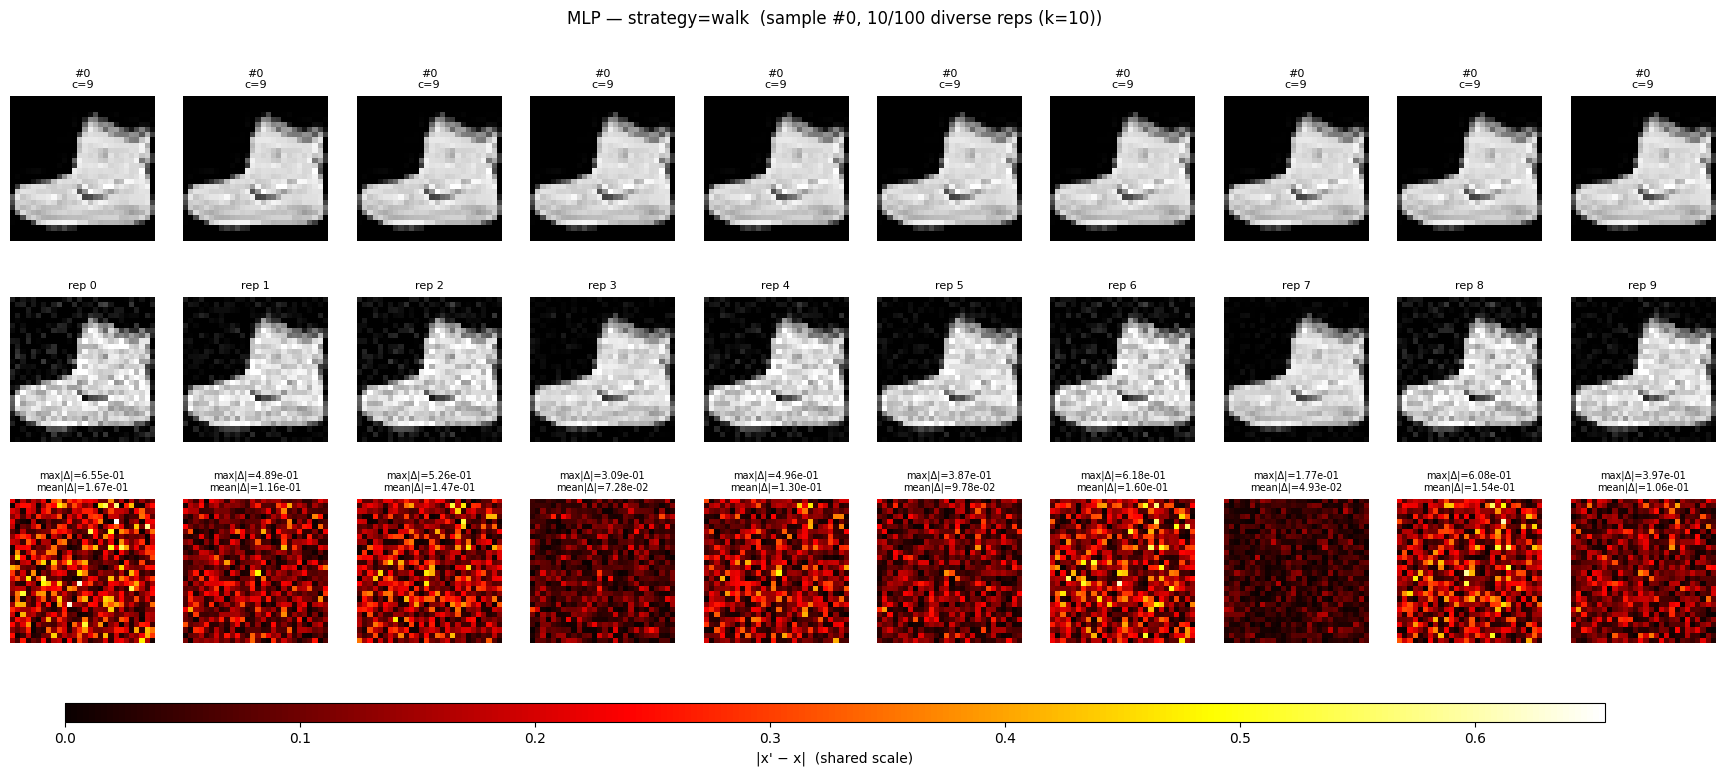

In [18]:
import matplotlib.pyplot as plt

def to_img(x):
    arr = x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.array(x)
    return arr.reshape(28, 28)

if STRATEGY == "walk":
    # Show (diverse) representatives for the first sample with at least one rep.
    # Each column = one representative; rows = original / augmented / |difference|.
    sample_r = next((r for r in results if r["found"]), None)
    if sample_r is None:
        print("No representatives found for any sample.")
    else:
        xps_all = sample_r["xps"]
        x_orig  = sample_r["x_orig"]

        # Apply diversity selection if requested
        if USE_DIVERSITY and len(xps_all) > K_DIVERSE:
            x0_ref = x_orig.flatten().unsqueeze(0) if MODEL_TYPE != "cnn" else x_orig.unsqueeze(0)
            xps = select_diverse_representatives(xps_all, x0_ref, k=K_DIVERSE)
            title_suffix = f"{len(xps)}/{len(xps_all)} diverse reps (k={K_DIVERSE})"
        else:
            xps = xps_all
            title_suffix = f"{len(xps)} reps"

        if not xps:
            print("No representatives to display.")
        else:
            n_reps    = len(xps)
            orig_img  = to_img(x_orig)
            aug_imgs  = [to_img(xp.squeeze(0)) for xp in xps]
            diff_imgs = [np.abs(a - orig_img) for a in aug_imgs]
            shared_vmax = max(d.max() for d in diff_imgs) if diff_imgs else 1.0

            fig, axes = plt.subplots(3, n_reps, figsize=(2.2 * n_reps, 7.5))
            if n_reps == 1:
                axes = axes[:, np.newaxis]
            fig.subplots_adjust(bottom=0.12)

            for col, (ia, idiff) in enumerate(zip(aug_imgs, diff_imgs)):
                axes[0, col].imshow(orig_img, cmap="gray",
                                    vmin=orig_img.min(), vmax=orig_img.max())
                axes[0, col].set_title(f"#{sample_r['idx']}\nc={sample_r['c']}", fontsize=8)
                axes[0, col].axis("off")

                axes[1, col].imshow(ia, cmap="gray",
                                    vmin=orig_img.min(), vmax=orig_img.max())
                axes[1, col].set_title(f"rep {col}", fontsize=8)
                axes[1, col].axis("off")

                im = axes[2, col].imshow(idiff, cmap="hot", vmin=0, vmax=shared_vmax)
                axes[2, col].axis("off")
                axes[2, col].set_title(
                    f"max|Δ|={idiff.max():.2e}\nmean|Δ|={idiff.mean():.2e}", fontsize=7
                )

            axes[0, 0].set_ylabel("Original",     fontsize=10, rotation=0, labelpad=55)
            axes[1, 0].set_ylabel("Augmented",    fontsize=10, rotation=0, labelpad=55)
            axes[2, 0].set_ylabel("|Difference|", fontsize=10, rotation=0, labelpad=55)

            cbar_ax = fig.add_axes([0.15, 0.03, 0.70, 0.025])
            fig.colorbar(im, cax=cbar_ax, orientation="horizontal",
                         label="|x' − x|  (shared scale)")

            fig.suptitle(
                f"{MODEL_TYPE.upper()} — strategy=walk  "
                f"(sample #{sample_r['idx']}, {title_suffix})",
                fontsize=12
            )
            plt.show()

else:
    # activation / margin: one rep per sample — show one column per sample
    found_results = [r for r in results if r["found"]]

    if not found_results:
        print("No augmented samples to display.")
    else:
        N_SHOW    = len(found_results)
        orig_imgs = [to_img(r["x_orig"]) for r in found_results]
        aug_imgs  = [to_img(r["xp"].squeeze(0)) for r in found_results]
        diff_imgs = [np.abs(a - o) for o, a in zip(orig_imgs, aug_imgs)]

        shared_vmax = max(d.max() for d in diff_imgs)
        shared_vmax = shared_vmax if shared_vmax > 0 else 1.0

        fig, axes = plt.subplots(3, N_SHOW, figsize=(2.2 * N_SHOW, 7.5))
        if N_SHOW == 1:
            axes = axes[:, np.newaxis]
        fig.subplots_adjust(bottom=0.12)

        for col, r in enumerate(found_results):
            io = orig_imgs[col]; ia = aug_imgs[col]; idiff = diff_imgs[col]

            axes[0, col].imshow(io, cmap="gray", vmin=io.min(), vmax=io.max())
            axes[0, col].set_title(f"#{r['idx']}\nc={r['c']}", fontsize=8)
            axes[0, col].axis("off")

            axes[1, col].imshow(ia, cmap="gray", vmin=io.min(), vmax=io.max())
            axes[1, col].set_title(f"c={r['c']}", fontsize=8)
            axes[1, col].axis("off")

            im = axes[2, col].imshow(idiff, cmap="hot", vmin=0, vmax=shared_vmax)
            axes[2, col].axis("off")
            axes[2, col].set_title(
                f"max|Δ|={idiff.max():.2e}\nmean|Δ|={idiff.mean():.2e}", fontsize=7
            )

        axes[0, 0].set_ylabel("Original",     fontsize=10, rotation=0, labelpad=55)
        axes[1, 0].set_ylabel("Augmented",    fontsize=10, rotation=0, labelpad=55)
        axes[2, 0].set_ylabel("|Difference|", fontsize=10, rotation=0, labelpad=55)

        cbar_ax = fig.add_axes([0.15, 0.03, 0.70, 0.025])
        fig.colorbar(im, cax=cbar_ax, orientation="horizontal",
                     label="|x' − x|  (shared scale)")

        fig.suptitle(
            f"{MODEL_TYPE.upper()} — strategy={STRATEGY}  ({N_SHOW} samples)",
            fontsize=12
        )
        plt.show()

## Pilot run: walk + diversity selection — timing & visualisation

Runs the full MCMC walk on `N_PILOT` samples, collects up to `NB_AUG_WALK` representatives,
applies greedy farthest-point diversity selection to keep `K_FINAL`, and plots one figure per
sample. The measured per-sample time is extrapolated to the full dataset to estimate the wall
time for a complete augmentation run.

To get the CNN estimate: change `MODEL_TYPE = "cnn"` in the Config cell, re-run from
**Load model** onwards, then re-run this cell.

  sample 0: 100 reps found  →  10 kept (diverse)
  sample 1: 100 reps found  →  10 kept (diverse)
  sample 2: 100 reps found  →  10 kept (diverse)

Pilot  : 3 samples in 4.6s  (1.55 s/sample)

── Time extrapolation (walk + diversity, MLP, 56680 samples) ──
  ≈ 1460 min   (24.3 h)

Notes:
  • The above estimate is for MLP with nb_aug_points=100, max_steps=5000.
  • Re-run with MODEL_TYPE='cnn' (and reload the model) to get the CNN estimate.


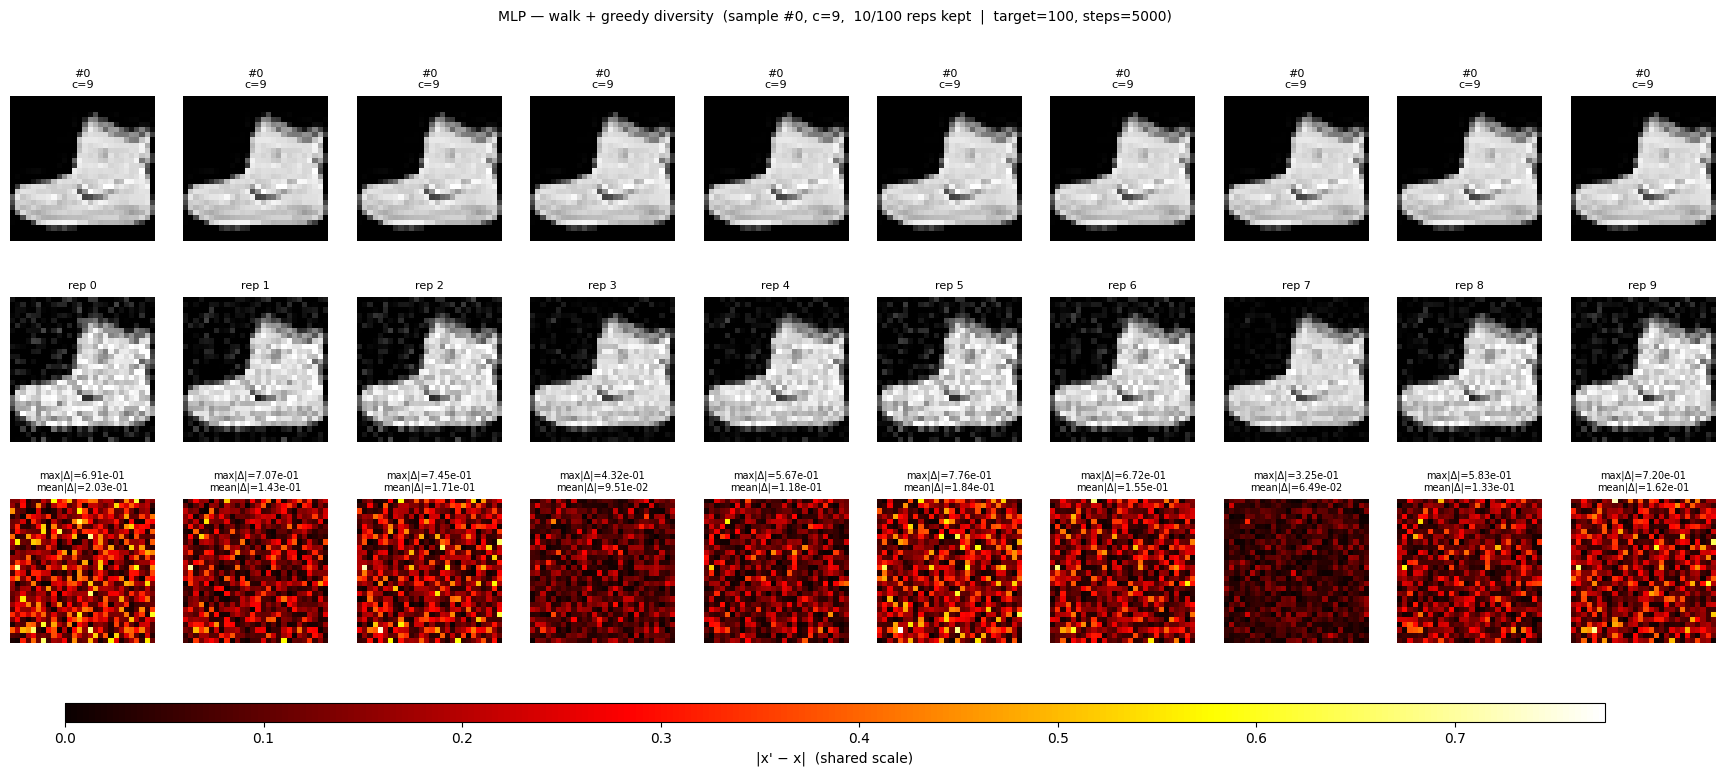

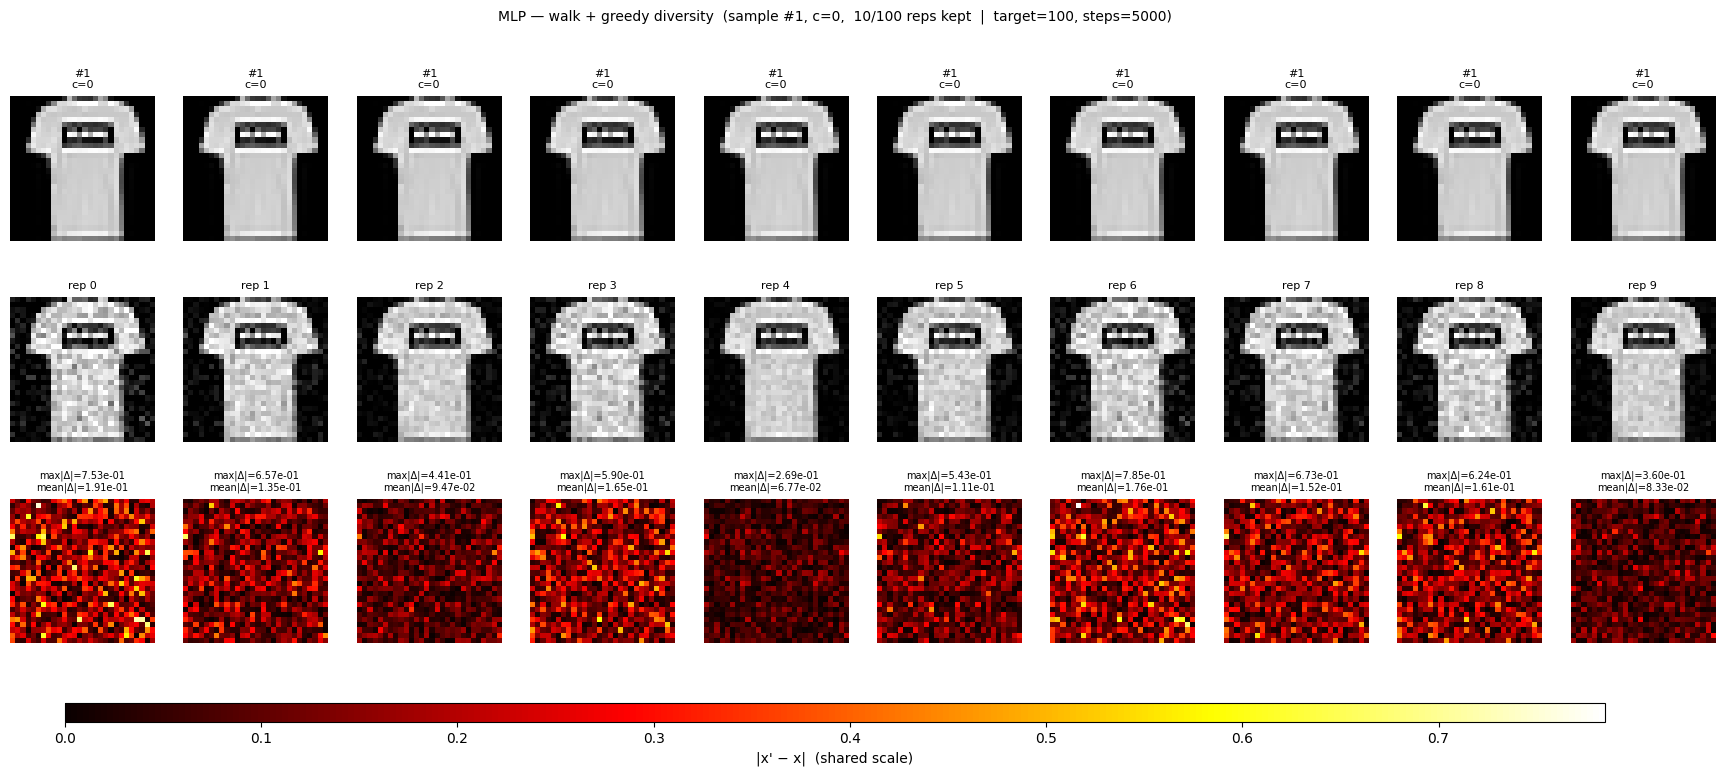

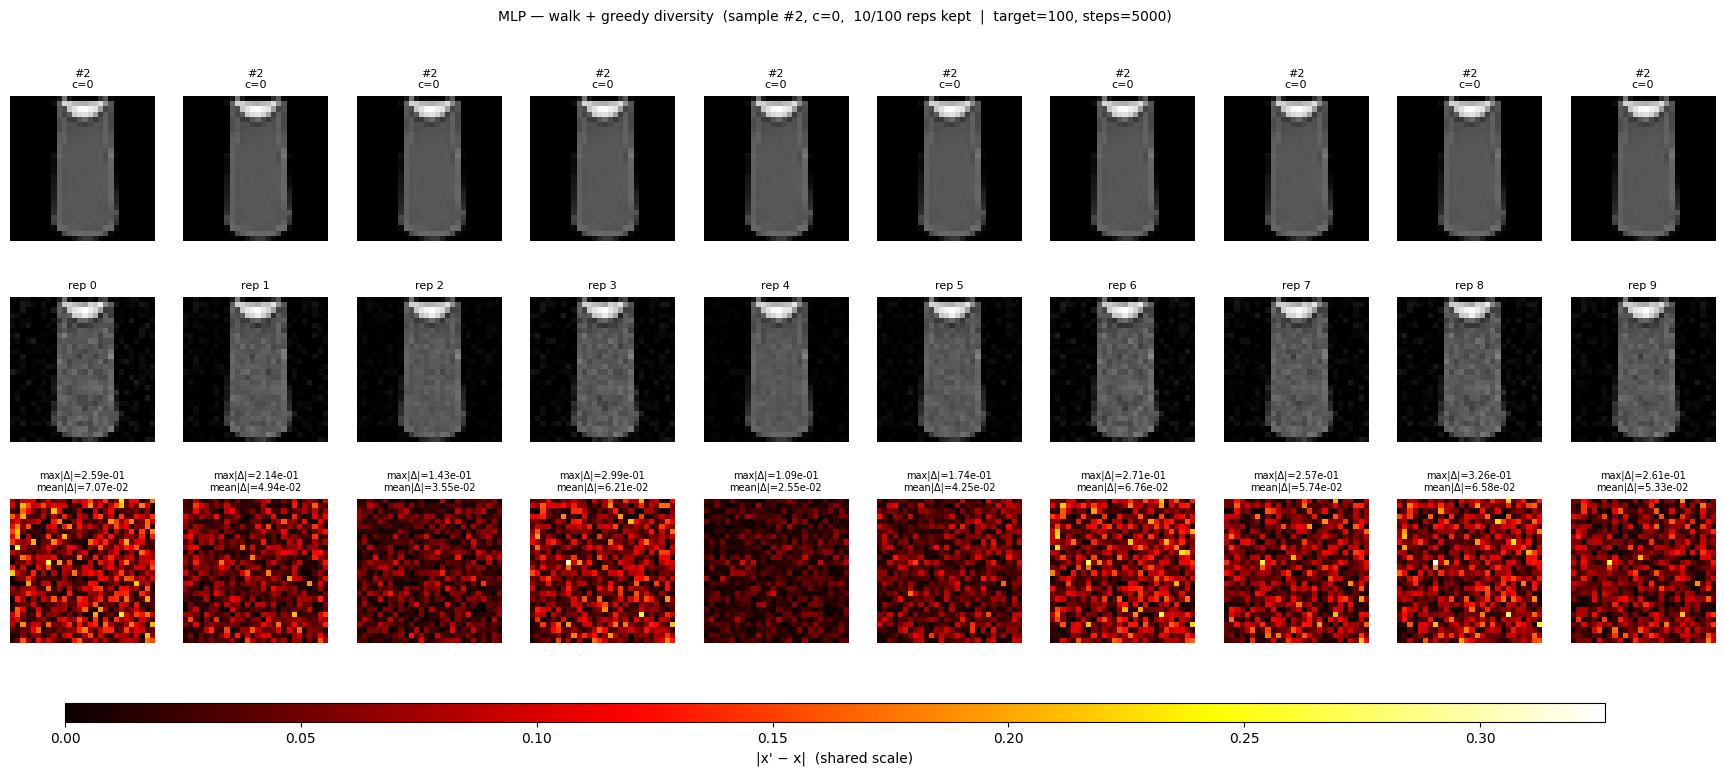

In [19]:
# ─── Parameters ───────────────────────────────────────────────────────────────
N_PILOT        = 3      # number of samples to process in this cell
NB_AUG_WALK    = 100    # collect up to this many reps per sample (walk)
MAX_STEPS_WALK = 5000   # hard cap on walk steps
K_FINAL        = 10     # diverse reps to keep (greedy farthest-point)

# ─── Walk + diversity selection on N_PILOT samples ───────────────────────────
pilot_results = []
rng_pilot     = np.random.default_rng(SEED + 99)   # fresh rng, separate from above cells
n_total       = len(dataset)

t_start = time.perf_counter()

for idx in range(N_PILOT):
    x_i, c_i = dataset[idx]
    c_i = int(c_i)

    if MODEL_TYPE == "cnn":
        x_b    = x_i.unsqueeze(0)
        x_i_in = x_i.unsqueeze(0)
        A_i, b_i, _ = build_cnn_all_polytopes(model, {BITS: qmodel}, x_b, c_i)
    else:
        x_b    = x_i.flatten().unsqueeze(0)
        x_i_in = x_i.flatten().unsqueeze(0)
        A_i, b_i, _ = build_all_polytopes(model, {BITS: qmodel}, x_b, c_i)

    A_np_i = A_i.detach().cpu().numpy()
    b_np_i = b_i.detach().cpu().numpy()

    reps_all = find_augmented_points_walk(
        x_i_in, A_np_i, b_np_i, qmodel,
        nb_aug_points=NB_AUG_WALK,
        max_steps=MAX_STEPS_WALK,
        rng=rng_pilot,
    )
    reps = (select_diverse_representatives(reps_all, x_i_in, k=K_FINAL)
            if len(reps_all) > K_FINAL else reps_all)

    pilot_results.append({
        "idx": idx, "x_orig": x_i, "c": c_i,
        "reps": reps, "n_found": len(reps_all),
    })
    print(f"  sample {idx}: {len(reps_all):3d} reps found  →  {len(reps)} kept (diverse)")

elapsed = time.perf_counter() - t_start
t_per   = elapsed / N_PILOT

print(f"\nPilot  : {N_PILOT} samples in {elapsed:.1f}s  ({t_per:.2f} s/sample)")
print(f"\n── Time extrapolation ({'walk + diversity, ' + MODEL_TYPE.upper()}, {n_total} samples) ──")
print(f"  ≈ {t_per * n_total / 60:.0f} min   ({t_per * n_total / 3600:.1f} h)")
print(f"\nNotes:")
print(f"  • The above estimate is for {MODEL_TYPE.upper()} with "
      f"nb_aug_points={NB_AUG_WALK}, max_steps={MAX_STEPS_WALK}.")
print(f"  • Re-run with MODEL_TYPE='cnn' (and reload the model) to get the CNN estimate.")

# ─── Plot: one figure per sample ──────────────────────────────────────────────
for r in pilot_results:
    xps    = r["reps"]
    n_reps = len(xps)

    if n_reps == 0:
        print(f"Sample #{r['idx']}: no representatives found — skipping.")
        continue

    orig_img  = to_img(r["x_orig"])
    aug_imgs  = [to_img(xp.squeeze(0)) for xp in xps]
    diff_imgs = [np.abs(a - orig_img) for a in aug_imgs]
    shared_vmax = max(d.max() for d in diff_imgs) if diff_imgs else 1.0

    fig, axes = plt.subplots(3, n_reps, figsize=(2.2 * n_reps, 7.5))
    if n_reps == 1:
        axes = axes[:, np.newaxis]
    fig.subplots_adjust(bottom=0.12)

    for col, (ia, idiff) in enumerate(zip(aug_imgs, diff_imgs)):
        axes[0, col].imshow(orig_img, cmap="gray",
                            vmin=orig_img.min(), vmax=orig_img.max())
        axes[0, col].set_title(f"#{r['idx']}\nc={r['c']}", fontsize=8)
        axes[0, col].axis("off")

        axes[1, col].imshow(ia, cmap="gray",
                            vmin=orig_img.min(), vmax=orig_img.max())
        axes[1, col].set_title(f"rep {col}", fontsize=8)
        axes[1, col].axis("off")

        im = axes[2, col].imshow(idiff, cmap="hot", vmin=0, vmax=shared_vmax)
        axes[2, col].axis("off")
        axes[2, col].set_title(
            f"max|Δ|={idiff.max():.2e}\nmean|Δ|={idiff.mean():.2e}", fontsize=7
        )

    axes[0, 0].set_ylabel("Original",     fontsize=10, rotation=0, labelpad=55)
    axes[1, 0].set_ylabel("Augmented",    fontsize=10, rotation=0, labelpad=55)
    axes[2, 0].set_ylabel("|Difference|", fontsize=10, rotation=0, labelpad=55)

    cbar_ax = fig.add_axes([0.15, 0.03, 0.70, 0.025])
    fig.colorbar(im, cax=cbar_ax, orientation="horizontal",
                 label="|x' − x|  (shared scale)")

    fig.suptitle(
        f"{MODEL_TYPE.upper()} — walk + greedy diversity  "
        f"(sample #{r['idx']}, c={r['c']},  "
        f"{n_reps}/{r['n_found']} reps kept  |  "
        f"target={NB_AUG_WALK}, steps={MAX_STEPS_WALK})",
        fontsize=10,
    )
    plt.show()